# Step 1: Import the required libraries

In [2]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

import torch
from torch import nn

# Step 2: Generate sample dataset

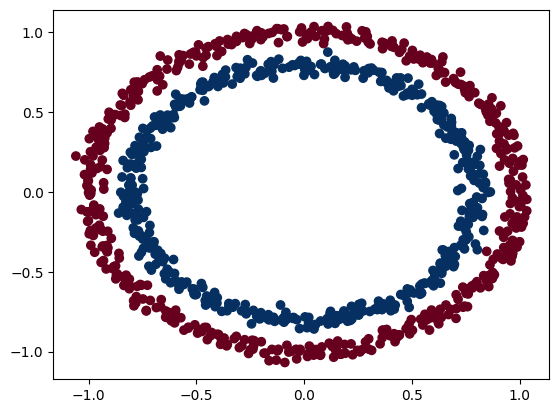

In [3]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=1000,
    noise=0.03,
    random_state=42,
)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu);

In [4]:
# Convert to tensors and split into train and test sets
import torch
from sklearn.model_selection import train_test_split

# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42
)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

# Step 3: Check and set model to run on the available Device type - CPU / GPU

In [5]:
# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Step 4: Create the Model class accepting following parameters  

a. Number of Hidden Layers  

b. linear or non-linear model flag

In [13]:
# Build model with non-linear activation function
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self, hiddenLayersCount, linearFlag):
        super().__init__()

        layers = []

        # Add input layer
        layers.append (nn.Linear(in_features = 2, out_features = 10))

        # Add non-linearity if user requested
        if not linearFlag: layers.append (nn.ReLU())

        for count in range(1):

          # Add hidden layer
          layers.append (nn.Linear(in_features = 10, out_features = 10))

          # Add non-linearity if user requested
          if not linearFlag: layers.append (nn.ReLU())

        # Add output layer
        layers.append (nn.Linear(in_features = 10, out_features = 1))
        # Add non-linearity if user requested
        if not linearFlag: layers.append (nn.ReLU())

        self.network = nn.Sequential(*layers)


    def forward(self, x):
      # Intersperse the ReLU activation function between layers
      # return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
      return self.network(x)



# 4. Send data to the target device

In [7]:
# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Step 5: Add Accuracy check and loss funtion

In [8]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

# loss_fn = nn.BCELoss() # Requires sigmoid on input
loss_fn = nn.BCEWithLogitsLoss() # Does not require sigmoid on input


# Step 7: Add function to plot graph

In [9]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):

    # Put everything to CPU (works better with NumPy + Matplotlib)
    import matplotlib.pyplot as plt
    import numpy as np

    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

# Step 8: Function to fit the model, accepting following parameters inputted by the User  

a. Number of epochs  

b. Number of hidden layers  

c. Linear flag

In [16]:
# Fit the model

def fitModel(epochs, hiddenLayersCount, linearFlag):

  torch.manual_seed(42)

  model_3 = CircleModelV2(hiddenLayersCount, linearFlag).to(device)
  print(model_3)

  optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

  for epoch in range(epochs):

      # 1. Forward pass
      y_logits = model_3(X_train).squeeze()
      y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

      # 2. Calculate loss and accuracy
      loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss calculates loss using logits
      acc = accuracy_fn(y_true=y_train,
                        y_pred=y_pred)

      # 3. Optimizer zero grad
      optimizer.zero_grad()

      # 4. Loss backward
      loss.backward()

      # 5. Optimizer step
      optimizer.step()

      ### Testing
      model_3.eval()
      with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_3(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits)) # logits -> prediction probabilities -> prediction labels
        # 2. Calculate loss and accuracy
        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test,
                              y_pred=test_pred)

      # Print out what's happening
      if epoch % 100 == 0:
          print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Accuracy: {test_acc:.2f}%")

  plt.figure(figsize=(12, 6))
  plt.subplot(1, 2, 1)
  plt.title("Train")
  plot_decision_boundary(model_3, X_train, y_train)
  plt.subplot(1, 2, 2)
  plt.title("Test")
  plot_decision_boundary(model_3, X_test, y_test)

# Step 9: Form to accept inputs from user, fit the model and render the graph

Output()

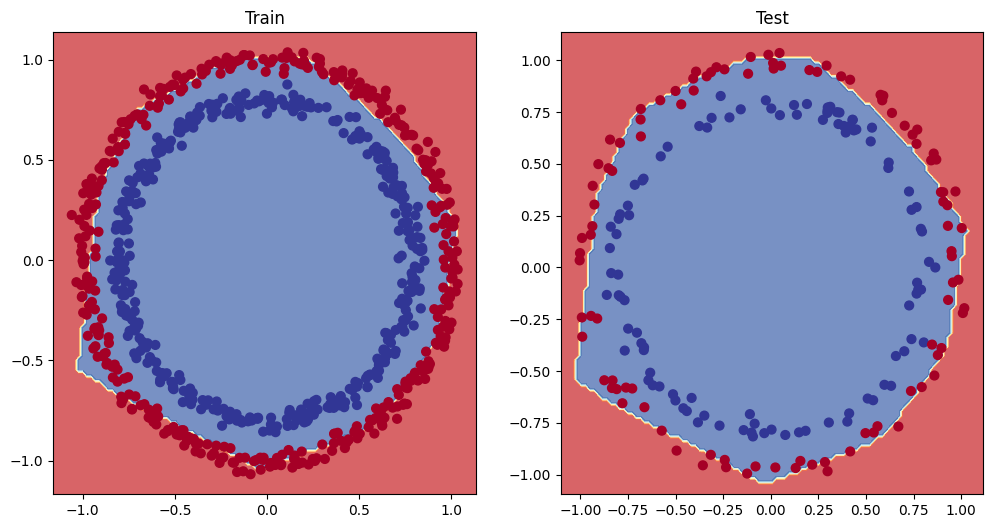

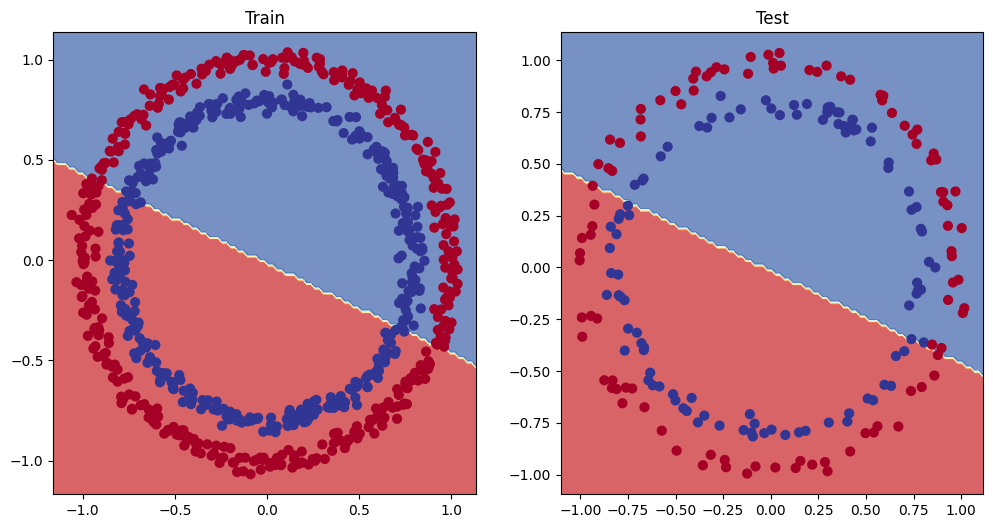

In [17]:
import ipywidgets as widgets
from IPython.display import display, clear_output


# 1. Create the dropdown widget

epoch = widgets.Dropdown(
    options=['500', '1000', '1500'],
    value='500',
    description='Epoch:',
    layout=widgets.Layout(width='12%')
)


hiddenLayers = widgets.Dropdown(
    options=['1', '2', '3'],
    value='1',
    description='Layers:',
    layout=widgets.Layout(width='12%')
)

linear = widgets.Dropdown(
    options=['Yes', 'No'],
    value='Yes',
    description='Linear:',
    layout=widgets.Layout(width='12%')
)


# 2. Create the submit button widget
submit_button = widgets.Button(
    description='Run Model',
    button_style='success', # Green color
    tooltip='Click to run model',
    icon='check',
    layout=widgets.Layout(width='10%'))


# 3. Create an output widget to handle the result display
output = widgets.Output()

# 4. Define what happens when the button is clicked
def on_button_clicked(b):
    with output:
        clear_output() # Clears the previous submission text

        epochCount = int(epoch.value)
        hiddenLayersCount = int(hiddenLayers.value)
        linearFlag = linear.value

        print(f"Form Submitted! You selected: {epochCount} {hiddenLayersCount} {linearFlag}")

        is_linear = True if linearFlag == "Yes" else False

        fitModel(epochCount, hiddenLayersCount, is_linear)

# 5. Link the button click event to the function
submit_button.on_click(on_button_clicked)

# 6. Display the form components
display(widgets.HBox([submit_button, epoch, hiddenLayers, linear]))

display(output)
